In [11]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, models, transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Execution Device:', device)

Execution Device: cuda


In [12]:
IMG_SIZE = 224

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Oxford-IIIT Pet 데이터셋 로드
full = datasets.OxfordIIITPet(
    root='./data', split='trainval', target_types='category',
    download=True, transform=train_tf
)

eval_full = datasets.OxfordIIITPet(
    root='./data', split='trainval', target_types='category',
    download=True, transform=test_tf
)

mask_data = datasets.OxfordIIITPet(
    root='./data', split='trainval', target_types='segmentation',
    download=True, transform=None
)

num_classes = 37
n_train = int(0.8 * len(full))
n_val = len(full) - n_train
split = random_split(range(len(full)), [n_train, n_val], generator=torch.Generator().manual_seed(SEED))

# 검증 및 시연을 위한 부분집합(Subset) 설정
"""train_set = Subset(full, split[0].indices[:min(128, n_train)])
val_set = Subset(eval_full, split[1].indices[:min(20, n_val)])

train_loader = DataLoader(train_set, batch_size=8, shuffle=True, num_workers=0)
val_loader = DataLoader(val_set, batch_size=8, shuffle=False, num_workers=0)

print(f'Total Dataset: {len(full)} | Classes: {num_classes}')
print(f'Train subset: {len(train_set)} | Val subset: {len(val_set)}')"""
# 기존 제한적인 Subset 대신 전체 Split 데이터셋을 사용
train_set = Subset(full, split[0].indices)
val_set = Subset(eval_full, split[1].indices)

train_loader = DataLoader(train_set, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train samples: {len(train_set)} | Val samples: {len(val_set)}')

Train samples: 2944 | Val samples: 736


In [ ]:
weights = None # ResNet50_Weights.DEFAULT 설정하여 사전학습 가중치 사용
model = models.resnet50(weights=weights)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()

# 백본 unfreeze, FC 층 학습
for p in model.parameters():
    p.requires_grad = True
#for p in model.fc.parameters():
    #p.requires_grad = True

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

def run_epoch(loader, training=True):
    model.train(training)
    total_loss = total_correct = total = 0
    for x, target in loader:
        y = target.to(device)
        x = x.to(device)
        if training:
            optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        if training:
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)
    return total_loss / total, total_correct / total

EPOCHS = 10
for epoch in range(EPOCHS):
    tr_loss, tr_acc = run_epoch(train_loader, True)
    va_loss, va_acc = run_epoch(val_loader, False)
    #print(f'Epoch {epoch+1}/{EPOCHS} | Train Acc: {tr_acc:.3f} | Val Acc: {va_acc:.3f}')
    print(f'Epoch {epoch+1}/{EPOCHS} | Train Loss: {tr_loss:.4f} Acc: {tr_acc:.3f} | Val Loss: {va_loss:.4f} Acc: {va_acc:.3f}')   
torch.save(model.state_dict(), 'resnet50_cam.pth')

Epoch 1/5 | Train Loss: 3.6671 Acc: 0.041 | Val Loss: 3.7502 Acc: 0.042
Epoch 2/5 | Train Loss: 3.5498 Acc: 0.058 | Val Loss: 3.6221 Acc: 0.046
Epoch 3/5 | Train Loss: 3.4196 Acc: 0.086 | Val Loss: 3.5603 Acc: 0.086
Epoch 4/5 | Train Loss: 3.3066 Acc: 0.105 | Val Loss: 3.4433 Acc: 0.103
Epoch 5/5 | Train Loss: 3.1808 Acc: 0.127 | Val Loss: 3.2808 Acc: 0.117


In [14]:
class HookCAM:
    def __init__(self, model):
        self.model = model.eval()
        self.activation = None
        self.handle = model.layer4.register_forward_hook(self._hook)
        
    def _hook(self, module, inp, out):
        self.activation = out.detach()
        
    def remove(self):
        self.handle.remove()
        
    @torch.no_grad()
    def cam(self, x, class_idx=None):
        logits = self.model(x)
        pred = logits.argmax(1) if class_idx is None else torch.tensor([class_idx], device=x.device)
        feat = self.activation
        w = self.model.fc.weight[pred]
        heat = (w[:, :, None, None] * feat).sum(1)
        heat = F.relu(heat)
        heat = F.interpolate(heat[:, None], size=x.shape[-2:], mode='bilinear', align_corners=False)[:, 0]
        heat = heat / (heat.amax(dim=(1, 2), keepdim=True) + 1e-8)
        return logits, pred, heat

class GradCAM:
    def __init__(self, model):
        self.model = model.eval()
        self.a = None
        self.g = None
        self.h1 = model.layer4.register_forward_hook(self._fh)
        self.h2 = model.layer4.register_full_backward_hook(self._bh)
        
    def _fh(self, m, i, o):
        self.a = o
        
    def _bh(self, m, gi, go):
        self.g = go[0]
        
    def remove(self):
        self.h1.remove()
        self.h2.remove()
        
    def cam(self, x, class_idx=None):
        x = x.requires_grad_(True)
        self.model.zero_grad(set_to_none=True)
        logits = self.model(x)
        pred = logits.argmax(1) if class_idx is None else class_idx
        score = logits[torch.arange(x.size(0), device=x.device), pred].sum()
        score.backward()
        alpha = self.g.mean(dim=(2, 3), keepdim=True)
        heat = F.relu((alpha * self.a).sum(1))
        heat = F.interpolate(heat[:, None], size=x.shape[-2:], mode='bilinear', align_corners=False)[:, 0]
        heat = heat / (heat.amax(dim=(1, 2), keepdim=True) + 1e-8)
        return logits.detach(), pred.detach(), heat.detach()

In [15]:
def mask_to_box(mask, threshold=0.5):
    ys, xs = np.where(mask >= threshold)
    if len(xs) == 0:
        return None
    return [int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())]

def iou(box1, box2):
    if box1 is None or box2 is None:
        return 0.0
    xa, ya = max(box1[0], box2[0]), max(box1[1], box2[1])
    xb, yb = min(box1[2], box2[2]), min(box1[3], box2[3])
    inter = max(0, xb - xa + 1) * max(0, yb - ya + 1)
    area1 = max(0, box1[2] - box1[0] + 1) * max(0, box1[3] - box1[1] + 1)
    area2 = max(0, box2[2] - box2[0] + 1) * max(0, box2[3] - box2[1] + 1)
    return inter / (area1 + area2 - inter + 1e-8)

def gt_box_from_segmentation(seg):
    arr = np.array(seg.resize((IMG_SIZE, IMG_SIZE), Image.NEAREST))
    return mask_to_box((arr != 2).astype(np.float32), threshold=0.5)

def denorm(x):
    mean = torch.tensor([0.485, 0.456, 0.406], device=x.device)[:, None, None]
    std = torch.tensor([0.229, 0.224, 0.225], device=x.device)[:, None, None]
    return (x * std + mean).clamp(0, 1)

Class Target: 22 | CAM IoU: 0.7462 | Grad-CAM IoU: 0.7462


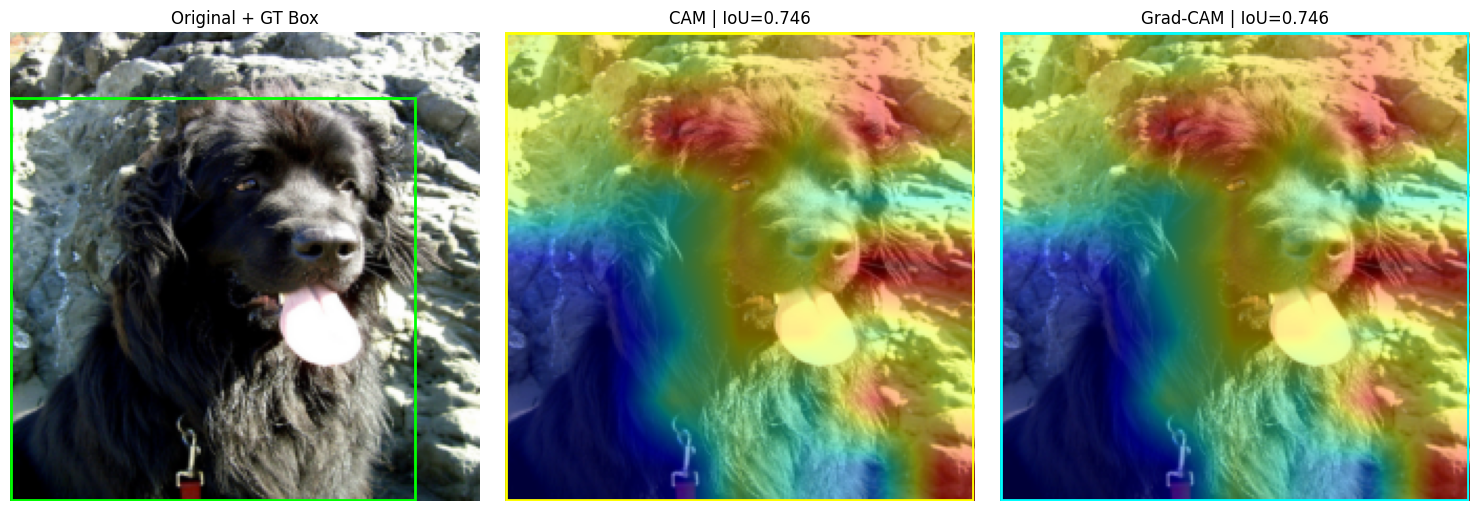

In [16]:
cam_engine = HookCAM(model)
grad_engine = GradCAM(model)

idx = 0
x, target = val_set[idx]
x1 = x.unsqueeze(0).to(device)

_, pred_cam, cam_map = cam_engine.cam(x1)
_, pred_grad, grad_map = grad_engine.cam(x1)

cam_np, grad_np = cam_map[0].cpu().numpy(), grad_map[0].cpu().numpy()

raw_index = val_set.indices[idx]
seg_path = mask_data._segs[raw_index]
gt = gt_box_from_segmentation(Image.open(seg_path))
cam_box, grad_box = mask_to_box(cam_np, 0.5), mask_to_box(grad_np, 0.5)

print(f"Class Target: {int(target)} | CAM IoU: {iou(cam_box, gt):.4f} | Grad-CAM IoU: {iou(grad_box, gt):.4f}")

img = denorm(x).permute(1, 2, 0).cpu().numpy()
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(img)
ax[0].set_title('Original + GT Box')

ax[1].imshow(img)
ax[1].imshow(cam_np, cmap='jet', alpha=0.45)
ax[1].set_title(f'CAM | IoU={iou(cam_box, gt):.3f}')

ax[2].imshow(img)
ax[2].imshow(grad_np, cmap='jet', alpha=0.45)
ax[2].set_title(f'Grad-CAM | IoU={iou(grad_box, gt):.3f}')

for a, b, c in [(ax[0], gt, 'lime'), (ax[1], cam_box, 'yellow'), (ax[2], grad_box, 'cyan')]:
    if b:
        x0, y0, x1b, y1b = b
        a.add_patch(plt.Rectangle((x0, y0), x1b - x0, y1b - y0, fill=False, color=c, lw=2))
    a.axis('off')

plt.tight_layout()
plt.savefig('cam_gradcam_result.png', dpi=200)
plt.show()

cam_engine.remove()
grad_engine.remove()

In [17]:
def evaluate_summary(engine, n=20, threshold=0.5):
    vals = []
    for j in range(min(n, len(val_set))):
        x, _ = val_set[j]
        x_tensor = x.unsqueeze(0).to(device)
        _, _, h = engine.cam(x_tensor)
        raw_index = val_set.indices[j]
        gt = gt_box_from_segmentation(Image.open(mask_data._segs[raw_index]))
        vals.append(iou(mask_to_box(h[0].cpu().numpy(), threshold), gt))
    vals = np.asarray(vals, dtype=np.float32)
    return float(vals.mean()), float((vals >= 0.5).mean()), len(vals)

cam_engine = HookCAM(model)
cam_mean, cam_rate, cam_n = evaluate_summary(cam_engine, n=20, threshold=0.5)
cam_engine.remove()

grad_engine = GradCAM(model)
grad_mean, grad_rate, grad_n = evaluate_summary(grad_engine, threshold=0.5)
grad_engine.remove()

print(f"[CAM Summary] Sample N={cam_n} | Mean IoU={cam_mean:.4f} | IoU>=0.5 Rate={cam_rate:.4f}")
print(f"[Grad-CAM Summary] Sample N={grad_n} | Mean IoU={grad_mean:.4f} | IoU>=0.5 Rate={grad_rate:.4f}")

[CAM Summary] Sample N=20 | Mean IoU=0.5231 | IoU>=0.5 Rate=0.6500
[Grad-CAM Summary] Sample N=20 | Mean IoU=0.5231 | IoU>=0.5 Rate=0.6500
